In [3]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [10]:
cf = pd.read_csv(r"C:\Users\priya\Desktop\PyCh_Pro\Churn_Analysis_and_Modelling\data\raw\telco_churn.csv")

In [11]:
cf.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [12]:
cf.shape

(7043, 21)

In [13]:
cf.sample(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
1384,4704-ERYFC,Female,0,Yes,No,22,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.25,1554,Yes
4689,2832-SCUCO,Female,0,No,No,2,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Electronic check,19.90,57.4,No
2015,5155-AZQPB,Female,0,Yes,Yes,28,Yes,Yes,DSL,No,...,No,No,No,No,Month-to-month,No,Mailed check,49.90,1410.25,No
6078,9691-HKOVS,Female,0,Yes,No,55,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Electronic check,90.15,4916.95,No
6282,1354-YZFNB,Male,0,Yes,Yes,4,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),19.55,68.8,No


In [14]:
cf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [15]:
cf.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [19]:
features = list(cf.columns)
features

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [27]:
num_features = cf.select_dtypes(include=['int64', 'float64']).columns
cat_features = cf.select_dtypes(include=['object', 'category']).columns

### Univariate Analysis

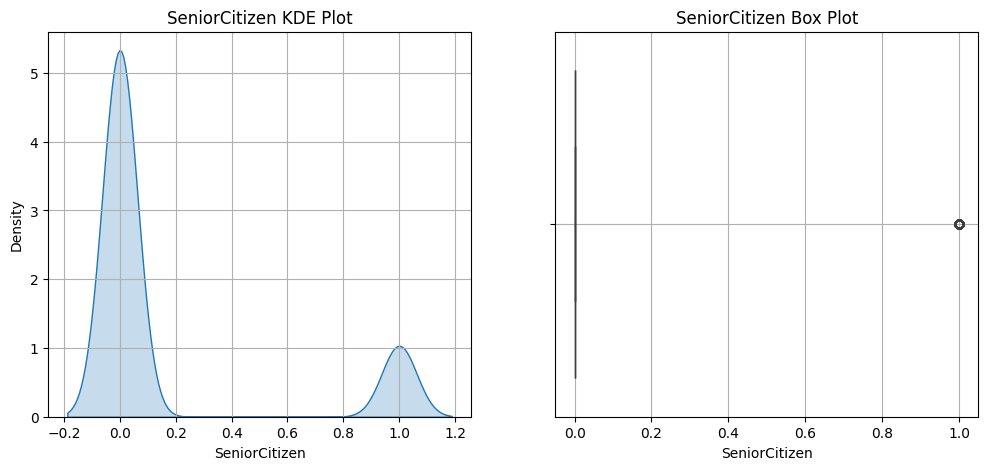

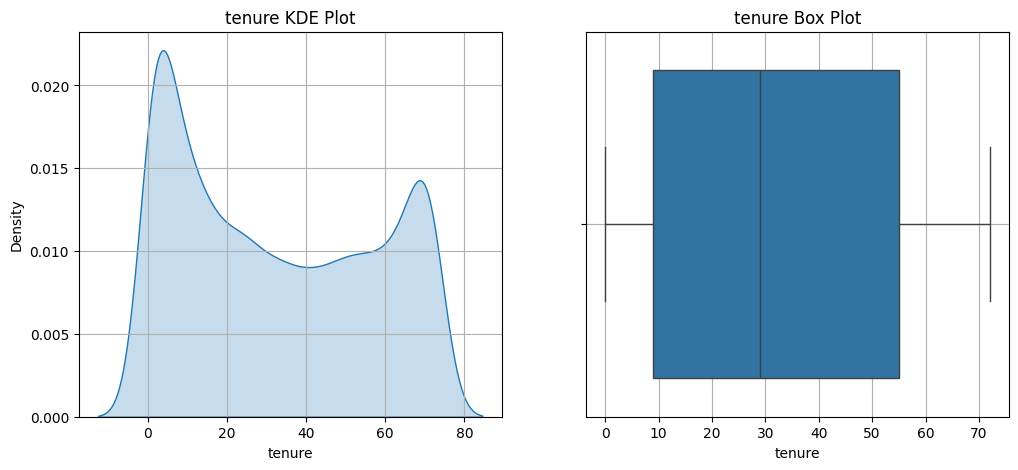

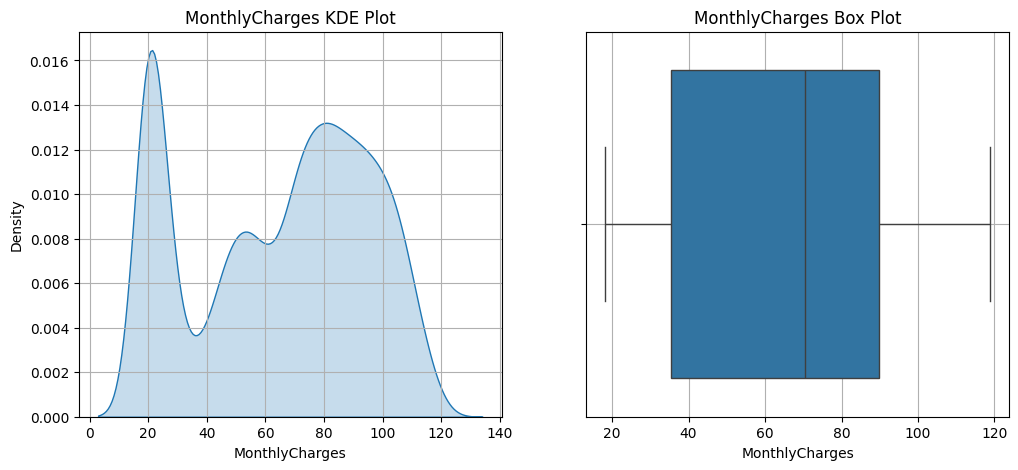

In [28]:
for i in num_features:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    sns.kdeplot(x = cf[i], data = cf,fill = True, ax=axes[0])
    axes[0].set_title(f"{i} KDE Plot")
    axes[0].grid(True)

    sns.boxplot(x = cf[i], data = cf, ax=axes[1])
    axes[1].set_title(f"{i} Box Plot")
    axes[1].grid(True)
    
    

In [57]:
cf["SeniorCitizen"].value_counts()

SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

<Axes: xlabel='SeniorCitizen'>

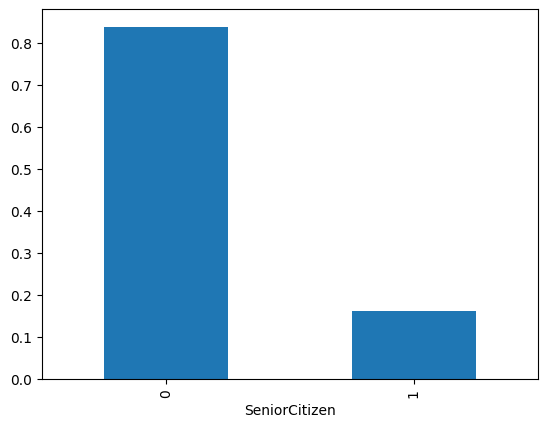

In [58]:
cf["SeniorCitizen"].value_counts(normalize=True).plot(kind="bar")

In [29]:
cf.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [39]:
cf.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

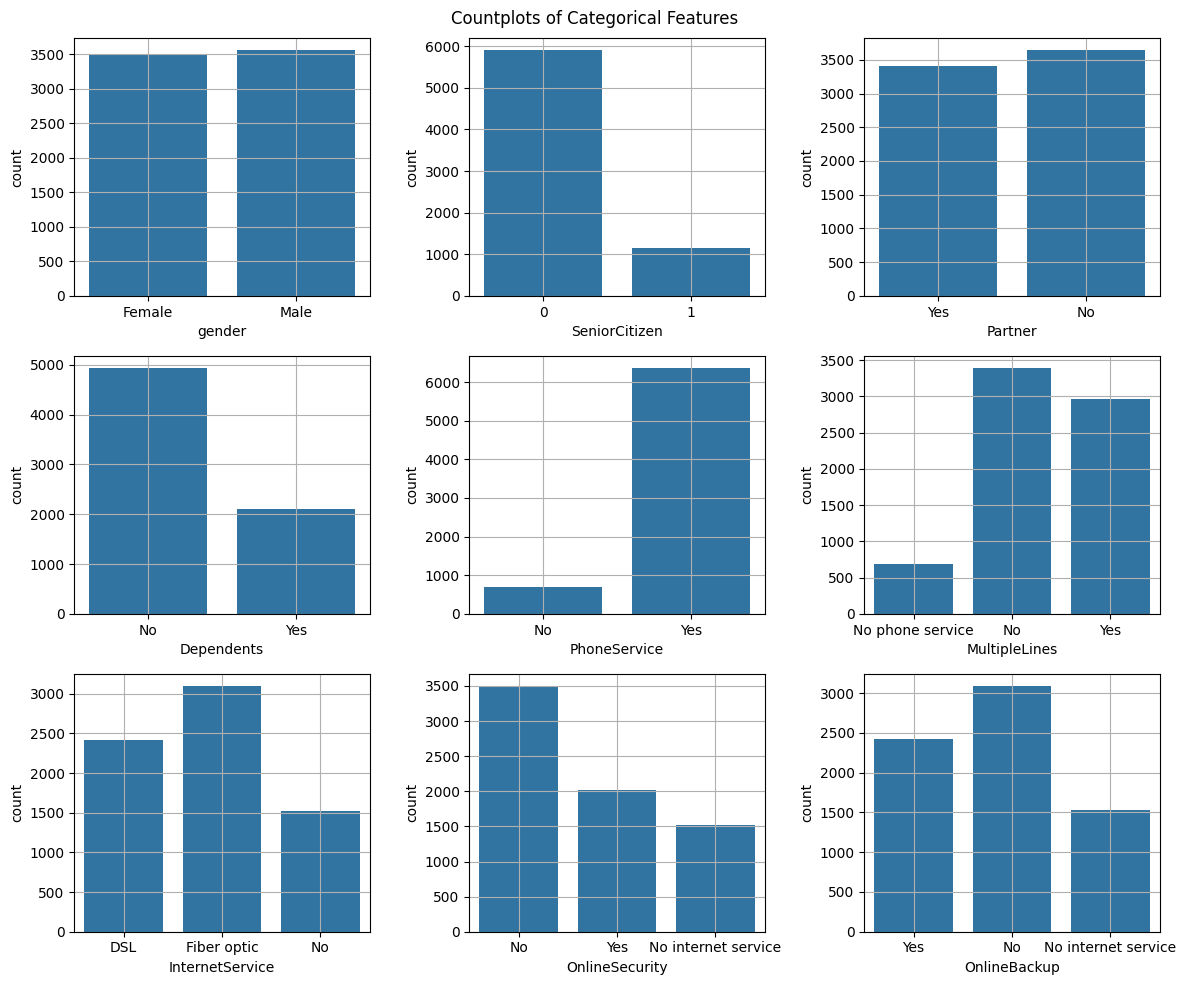

In [71]:
fig, axes = plt.subplots(3, 3, figsize=(12, 10))

sns.countplot(x="gender", data=cf, ax=axes[0, 0])
axes[0, 0].grid(True)

sns.countplot(x="SeniorCitizen", data=cf, ax=axes[0, 1])
axes[0, 1].grid(True)

sns.countplot(x="Partner", data=cf, ax=axes[0, 2])
axes[0, 2].grid(True)

sns.countplot(x="Dependents", data=cf, ax=axes[1, 0])
axes[1, 0].grid(True)

sns.countplot(x="PhoneService", data=cf, ax=axes[1, 1])
axes[1, 1].grid(True)

sns.countplot(x="MultipleLines", data=cf, ax=axes[1, 2])
axes[1, 2].grid(True)

sns.countplot(x = "InternetService", data = cf, ax = axes[2, 0])
axes[2, 0].grid(True)

sns.countplot(x = "OnlineSecurity", data = cf, ax = axes[2, 1])
axes[2, 1].grid(True)

sns.countplot(x = "OnlineBackup", data = cf, ax = axes[2, 2])
axes[2, 2].grid(True)

fig.suptitle("Countplots of Categorical Features")

plt.tight_layout()
plt.show()

In [56]:
cf.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

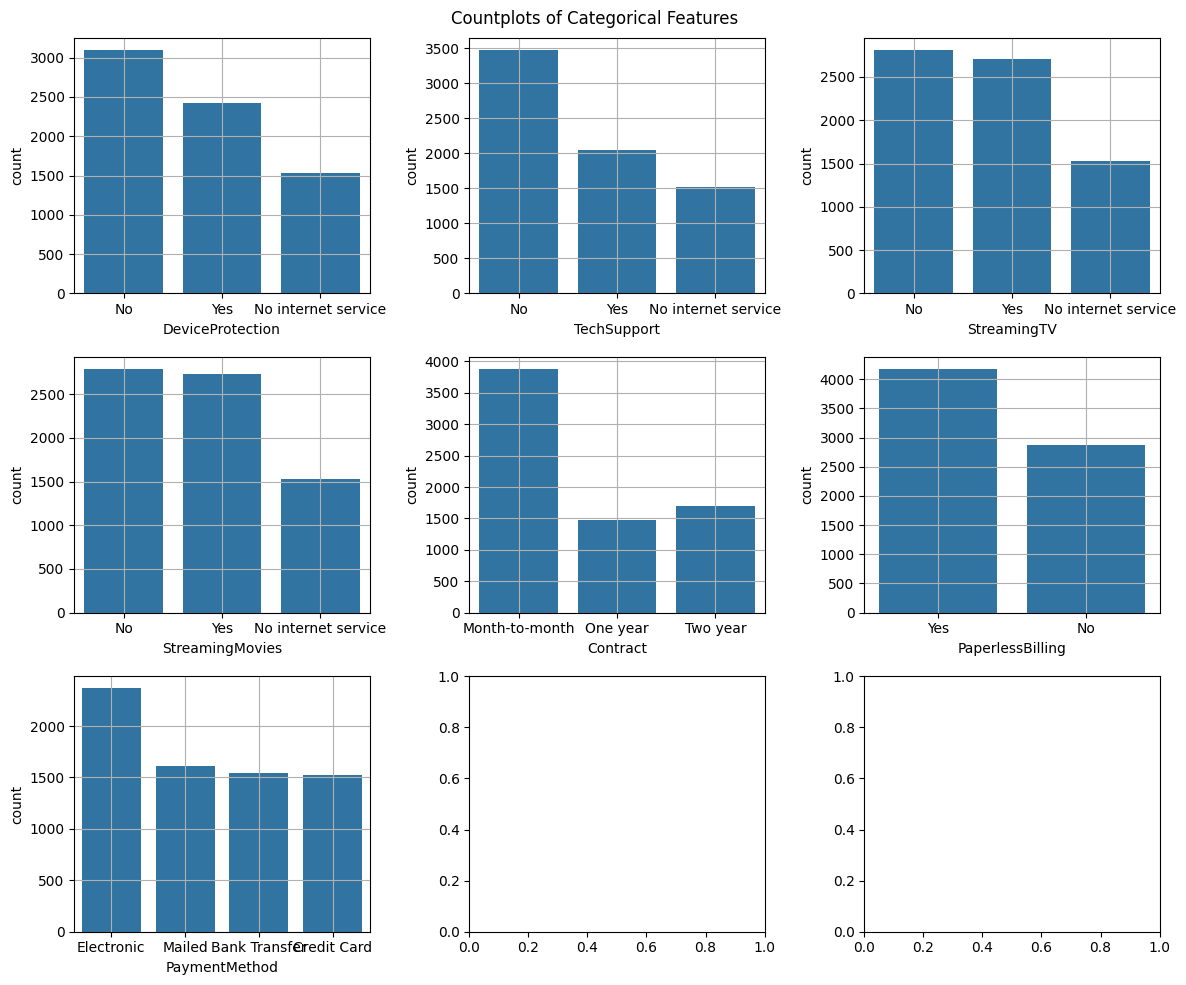

In [72]:
fig, axes = plt.subplots(3, 3, figsize=(12, 10))

sns.countplot(x = "DeviceProtection", data = cf, ax = axes[0,0])
axes[0,0].grid(True)

sns.countplot(x = "TechSupport", data = cf, ax = axes[0,1])
axes[0,1].grid(True)

sns.countplot(x = "StreamingTV", data = cf, ax = axes[0,2])
axes[0,2].grid(True)

sns.countplot(x = "StreamingMovies", data = cf, ax = axes[1, 0])
axes[1,0].grid(True)

sns.countplot(x = "Contract", data = cf, ax = axes[1,1])
axes[1,1].grid(True)

sns.countplot(x = "PaperlessBilling", data = cf, ax = axes[1, 2])
axes[1,2].grid(True)

cf['PaymentMethod'] = cf['PaymentMethod'].replace({
    'Electronic check': 'Electronic',
    'Mailed check': 'Mailed',
    'Bank transfer (automatic)': 'Bank Transfer',
    'Credit card (automatic)': 'Credit Card'
})

sns.countplot(x = "PaymentMethod", data = cf, ax = axes[2, 0])
axes[2,0].grid(True)

fig.suptitle("Countplots of Categorical Features")

plt.tight_layout()
plt.show()

In [69]:
cf["PaymentMethod"].value_counts()

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

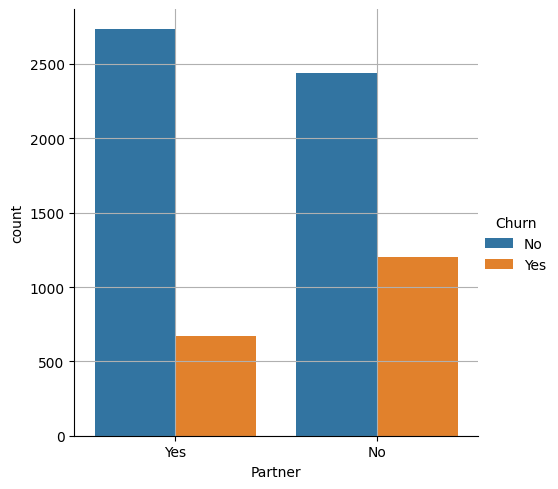

In [44]:
sns.catplot(x = "Partner", data = cf, kind = "count", hue = "Churn")
plt.grid(True)

### Multivariate Analysis